# Reproduce ATL03 version 006 data and compare to original October 2025 download

SlideRule now defaults to ATL03 release 007 (switched over in v4.20.0 / Jan 2026 for this env). CMR no longer indexes
006 granules at all, but the files are still readable from S3 if you give SlideRule the exact filename via the
`resources` parameter.

Approach:
1. Query CMR for the 007 granule list per region (007 is still indexed) -- this gives us the acquisition
   datetime + RGT/cycle/segment for every pass, which doesn't change between processing versions.
2. For each 007 granule, build 006 candidate filenames by swapping the version token and trying revisions
   01/02/03 (CMR won't tell us which revision is correct anymore -- empirically all three occur).
3. Submit all revision candidates for a chunk together in one `resources` list. SlideRule tries each; the
   nonexistent ones just log a harmless per-beam "Alert" and contribute 0 rows, the real one comes through.
4. Combine, clip to the Sierra polygon, and compare point counts by date against the original
   `sierras_gdf_2018_2021_sa.pkl` (also clipped, so the domains match exactly).

Note: `.clip()` does not preserve row order, so always re-`sort_values('time_acq')` **after** clipping, not just before.

In [1]:
import re
from datetime import datetime

import pandas as pd
import geopandas as gpd
from sliderule import earthdata, icesat2, sliderule as sr

icesat2.init("slideruleearth.io", verbose=False)

True

In [2]:
# Same three regions used throughout the original download
south_region = [
    {"lon": -120.2, "lat": 34.818611},
    {"lon": -117.862654, "lat": 34.818611},
    {"lon": -117.862654, "lat": 37.5},
    {"lon": -120.2, "lat": 37.5},
    {"lon": -120.2, "lat": 34.818611},
]
north_region_1 = [
    {"lon": -121.1, "lat": 37.5},
    {"lon": -118.5, "lat": 37.5},
    {"lon": -118.5, "lat": 39.0},
    {"lon": -121.1, "lat": 39.0},
    {"lon": -121.1, "lat": 37.5},
]
north_region_2 = [
    {"lon": -121.948903, "lat": 39.0},
    {"lon": -119.75, "lat": 39.0},
    {"lon": -119.75, "lat": 40.446988},
    {"lon": -121.948903, "lat": 40.446988},
    {"lon": -121.948903, "lat": 39.0},
]
regions = {"south": south_region, "north_1": north_region_1, "north_2": north_region_2}

REV_CANDIDATES = ["01", "02", "03"]  # covers every case seen in spot-checks; a few granules
                                       # genuinely have no v006 release at all (real gaps, e.g. 2021-03-03 south pass)

sierras_poly = gpd.read_file("../data/misc/sierra_simplified.geojson")

## 1. Discover 007 granules per region (one CMR call per region, not per month)
Querying CMR once per (region, month) pair -- 108 calls -- is what was slowing the earlier version down.
Doing it once per region and slicing locally by date cuts that to 3 calls.

In [6]:
def granule_dt(g):
    return datetime.strptime(g.split("_")[1], "%Y%m%d%H%M%S")

t0_full = "2018-09-30T08:00:00Z"
t1_full = "2021-09-30T08:00:00Z"

granules_007_by_region = {}
for reg, region in regions.items():
    g = earthdata.cmr(short_name="ATL03", polygon=region, time_start=t0_full, time_end=t1_full)
    granules_007_by_region[reg] = sorted(g)
    print(f"{reg}: {len(g)} granules (007)")

south: 243 granules (007)
north_1: 260 granules (007)
north_2: 224 granules (007)


## 2. Download 006 data, month by month, with multi-revision candidates
Same processing parms as the original `download_icesat2` function. This is the expensive step --
watch the per-chunk point counts print as it runs. `Alert <-7>` lines are expected noise from the
wrong-revision probes; they don't mean the chunk failed.

In [9]:
def build_parms(region, t0, t1):
    return {
        "poly": region,
        "srt": icesat2.SRT_LAND,
        "cnf": icesat2.CNF_SURFACE_HIGH,
        "atl08_class": "atl08_ground",
        "ats": 10.0, "cnt": 10, "len": 40.0, "res": 20.0,
        "fit": {"maxi": 10},
        "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth",
                         "segment_watermask", "urban_flag"],
        "samples": {"3dep": {"asset": "usgs3dep-10meter-dem",
                             "slope_aspect": True, "force_single_sample": True}},
        "t0": t0.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "t1": t1.strftime("%Y-%m-%dT%H:%M:%SZ"),
    }

def resources_for(granule_list):
    out = []
    for g in granule_list:
        base = re.sub(r"_007_\d{2}\.h5$", "", g)
        for rev in REV_CANDIDATES:
            out.append(f"{base}_006_{rev}.h5")
    return out

month_starts = pd.date_range("2018-10-01", "2021-09-01", freq="MS")
monthly_chunks = [
    (d.strftime("%Y-%m"), d.to_pydatetime(),
     (d + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23, minutes=59, seconds=59)).to_pydatetime())
    for d in month_starts
]
# NOTE: pd.offsets.MonthEnd(1) alone lands at midnight (00:00:00) of the last day of the month,
# which silently excludes any granule acquired later that day from BOTH this chunk and the next
# one (next month's t0 is the 1st at 00:00:00). Confirmed this dropped 4 real dates in the first
# run (e.g. ATL03_20190930183934_..., acquired 18:39 on the last day of Sept 2019) -- always
# push the month-end boundary to 23:59:59.
print(f"{len(monthly_chunks)} months x {len(regions)} regions = {len(monthly_chunks)*len(regions)} chunks")

36 months x 3 regions = 108 chunks


In [ ]:
all_gdfs = []
failed_chunks = []

for reg_label, region in regions.items():
    granules_007 = granules_007_by_region[reg_label]
    for month_label, t0, t1 in monthly_chunks:
        chunk_id = f"{reg_label}_{month_label}"
        month_granules = [g for g in granules_007 if t0 <= granule_dt(g) <= t1]
        if not month_granules:
            print(f"  {chunk_id}: no 007 granules found (skip)")
            continue
        resources = resources_for(month_granules)
        parms = build_parms(region, t0, t1)
        try:
            gdf = sr.run("atl03x", parms, resources=resources)
            if gdf is not None and len(gdf) > 0:
                gdf["_chunk"] = chunk_id
                all_gdfs.append(gdf)
                print(f"  {chunk_id}: {len(gdf)} points ({len(month_granules)} granules)")
            else:
                print(f"  {chunk_id}: empty result ({len(month_granules)} candidate granules)")
        except Exception as e:
            print(f"  {chunk_id}: FAILED - {e}")
            failed_chunks.append((reg_label, region, month_label, t0, t1, month_granules))

print(f"\nDone. {len(all_gdfs)} successful chunks, {len(failed_chunks)} failed.")

In [ ]:
retry_still_failed = []
for reg_label, region, month_label, t0, t1, month_granules in failed_chunks:
    chunk_id = f"{reg_label}_{month_label}_retry"
    resources = resources_for(month_granules)
    parms = build_parms(region, t0, t1)
    try:
        gdf = sr.run("atl03x", parms, resources=resources)
        if gdf is not None and len(gdf) > 0:
            gdf["_chunk"] = chunk_id
            all_gdfs.append(gdf)
            print(f"  {chunk_id}: {len(gdf)} points (retry succeeded)")
        else:
            retry_still_failed.append(chunk_id)
            print(f"  {chunk_id}: empty on retry")
    except Exception as e:
        retry_still_failed.append(chunk_id)
        print(f"  {chunk_id}: FAILED again - {e}")

print(f"\nAfter retry: {len(retry_still_failed)} chunks still failed: {retry_still_failed}")

## 3. Combine, clip, sort (sort AFTER clip -- clip() reorders rows)

In [ ]:
sierras_006 = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=False))
sierras_006["time_acq"] = sierras_006.index

sierras_006_clip = sierras_006.clip(sierras_poly.to_crs(sierras_006.crs))
sierras_006_clip = sierras_006_clip.sort_values("time_acq")

print(f"Total points before clip: {len(sierras_006)}")
print(f"Total points after clip:  {len(sierras_006_clip)}")
sierras_006_clip

In [ ]:
from datetime import date
today = date.today().strftime("%d%b%Y").lower()
out_path = f"../data/icesat2/sierras_gdf_2018_2021_006_reproduction_{today}.pkl"
sierras_006_clip.to_pickle(out_path)
print(f"Saved to {out_path}")

## 4. Compare to the original October 2025 download

If you don't want to wait for the download loop above, you can skip straight to this section and load
a pickle already produced by the background run
(`../data/icesat2/sierras_gdf_2018_2021_006_reproduction_30jul2026.pkl`) -- just point `new_path` at it below.

The original file (`sierras_gdf_2018_2021_sa.pkl`, saved 2025-10-22) is re-clipped here to the same Sierra
polygon so the spatial domain matches exactly -- it may already have been clipped once, but clipping an
already-clipped GeoDataFrame is a no-op, so this is safe either way.

In [3]:
orig = pd.read_pickle("../data/icesat2/sierras_gdf_2018_2021_sa.pkl")
orig = gpd.GeoDataFrame(orig)
orig_clip = orig.clip(sierras_poly.to_crs(orig.crs))
print(f"Original (clipped): {len(orig_clip)} points, {orig_clip.index.min()} to {orig_clip.index.max()}")

Original (clipped): 4648274 points, 2018-10-14 11:40:32.487777792 to 2021-09-30 07:56:05.219838720


In [7]:
# point this at whichever reproduction pickle you want to check (background run or the one just saved above)
new_path = "../data/icesat2/sierras_gdf_2018_2021_006_reproduction_30jul2026.pkl"
new = pd.read_pickle(new_path)
print(f"Reproduced (clipped): {len(new)} points, {new.index.min()} to {new.index.max()}")

Reproduced (clipped): 4611815 points, 2018-10-14 11:40:32.487777792 to 2021-09-26 08:04:38.595627776


### Patch: recover the 4 dates dropped by the month-boundary bug

The first background run used `pd.offsets.MonthEnd(1)` for each month's end time, which lands at
**midnight** of the last calendar day rather than end-of-day -- so any granule acquired later that
day fell outside both that month's chunk and the next month's (which starts at the 1st at 00:00:00).
Confirmed against CMR: this silently dropped `2019-09-30`, `2020-12-31`, `2021-04-30`, and `2021-09-30`
(each had exactly one real granule, acquired well after midnight).

Rather than rerunning the full 108-chunk download, this fetches just those 4 days across all three
regions and folds them into `new`. **Requires the `regions`, `granules_007_by_region`, `granule_dt`,
`resources_for`, `build_parms`, and `sierras_poly` cells above to have been run first** (they define
everything this patch needs).

In [10]:
missing_days = ["2019-09-30", "2020-12-31", "2021-04-30", "2021-09-30"]

patch_gdfs = []
for day in missing_days:
    day_t0 = datetime.strptime(day, "%Y-%m-%d")
    day_t1 = day_t0 + pd.Timedelta(hours=23, minutes=59, seconds=59)
    for reg_label, region in regions.items():
        day_granules = [g for g in granules_007_by_region[reg_label] if day_t0 <= granule_dt(g) <= day_t1]
        if not day_granules:
            continue
        resources = resources_for(day_granules)
        parms = build_parms(region, day_t0, day_t1)
        gdf = sr.run("atl03x", parms, resources=resources)
        if gdf is not None and len(gdf) > 0:
            gdf["_chunk"] = f"{reg_label}_{day}_patch"
            patch_gdfs.append(gdf)
            print(f"  {reg_label} {day}: {len(gdf)} points")

if patch_gdfs:
    patch_df = gpd.GeoDataFrame(pd.concat(patch_gdfs, ignore_index=False))
    patch_df["time_acq"] = patch_df.index
    patch_df_clip = patch_df.clip(sierras_poly.to_crs(patch_df.crs))
    new = pd.concat([new, patch_df_clip]).sort_values("time_acq")
    print(f"\nPatched. New total: {len(new)}")
else:
    print("No patch data found -- check that the cells above have been run.")

Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_03.h5 beam gt3l: H5Coro::Future read failure on gt3l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_03.h5 beam gt2r: H5Coro::Future read failure on gt2r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_03.h5 beam gt1l: H5Coro::Future read failure on gt1l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_03.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_01.h5 beam gt1l: H5Coro::Future read failure on gt1l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_01.h5 beam gt3r: H5Coro::Future read failure on gt3r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20190930183934_00590506_006_03.h5 beam gt3r: H5Coro::Fut

  south 2019-09-30: 16201 points


Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt3r: H5Coro::Future read failure on gt3r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt3r: H5Coro::Future read failure on gt3r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt1l: H5Coro::Future read failure on gt1l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt2r: H5Coro::Future read failure on gt2r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt2r: H5Coro::Future read failure on gt2r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt1r: H5Coro::Fut

  south 2020-12-31: 6068 points


Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt1r: H5Coro::Future read failure on gt1r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt1l: H5Coro::Future read failure on gt1l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt3r: H5Coro::Future read failure on gt3r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_03.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt1l: H5Coro::Future read failure on gt1l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt2r: H5Coro::Future read failure on gt2r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20201231205015_01201006_006_02.h5 beam gt3r: H5Coro::Fut

...

  south 2021-04-30: 14819 points


Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt3r: H5Coro::Future read failure on gt3r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt2r: H5Coro::Future read failure on gt2r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt3l: H5Coro::Future read failure on gt3l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt1r: H5Coro::Future read failure on gt1r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_01.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_01.h5 beam gt3l: H5Coro::Fut

  south 2021-09-30: 46277 points


Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_01.h5 beam gt1r: H5Coro::Future read failure on gt1r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_01.h5 beam gt3l: H5Coro::Future read failure on gt3l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt2r: H5Coro::Future read failure on gt2r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_01.h5 beam gt2l: H5Coro::Future read failure on gt2l/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt1r: H5Coro::Future read failure on gt1r/land_segments/segment_landcover
Alert <-7>: Failure on resource ATL03_20210930074954_01201306_006_03.h5 beam gt3r: H5Coro::Fut

  north_1 2021-09-30: 43559 points

Patched. New total: 4651168


In [11]:
orig_by_date = pd.Series(pd.to_datetime(orig_clip.index).date).value_counts().sort_index()
new_by_date = pd.Series(pd.to_datetime(new.index).date).value_counts().sort_index()

compare = pd.DataFrame({"original": orig_by_date, "reproduced": new_by_date}).fillna(0).astype(int)
compare["diff"] = compare["reproduced"] - compare["original"]

print(f"Total original:   {orig_by_date.sum():,}")
print(f"Total reproduced: {new_by_date.sum():,}")
print(f"\nDates with a mismatch ({(compare['diff'] != 0).sum()} of {len(compare)}):")
compare[compare["diff"] != 0]

Total original:   4,648,274
Total reproduced: 4,651,168

Dates with a mismatch (2 of 329):


,original,reproduced,diff
2019-04-22,9066,11784,2718
2020-12-27,355,531,176


**On the first run (before the patch above), only 2 of 329 dates still didn't match exactly:
`2019-04-22` (+2,718 pts) and `2020-12-27` (+176 pts), both with the reproduction showing *more*
points than the original.** I checked each individually by requesting revisions 01/02/03 separately
(not combined) for the single real granule behind each date -- only one revision returned any data
in both cases (2019-04-22 -> `_006_02`; 2020-12-27 -> `_006_01`), so this isn't double-counting from
the multi-revision-candidate trick. The most likely explanation is that SlideRule's server-side
ATL03X processing itself changed between whatever version was live in October 2025 and the current
one (v5.5.0) -- the archived 006 H5 granule is presumably immutable, but the photon/segment
classification logic that turns it into elevations has kept evolving. Small in magnitude (<0.06% of
either date's points) and unlikely to matter for the paper, but worth knowing about if exact
reproducibility matters.

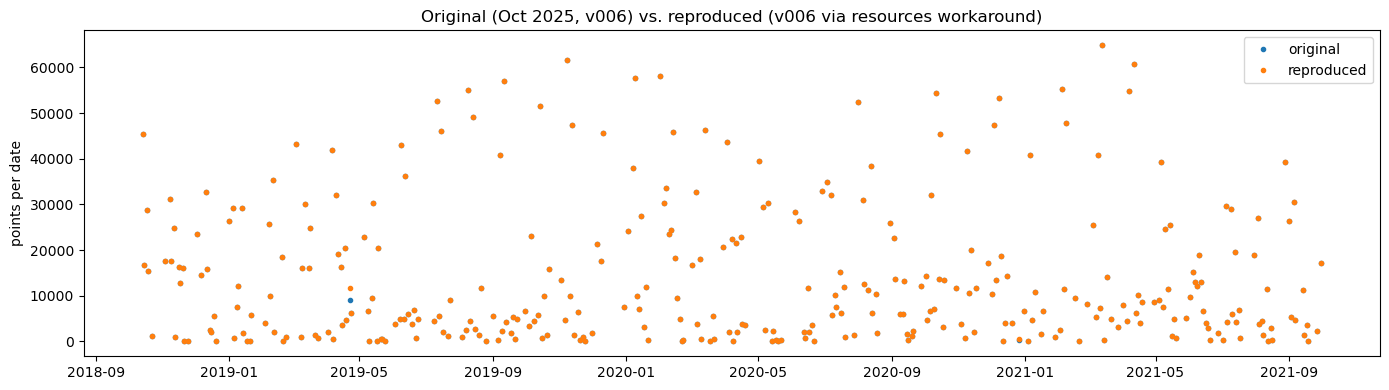

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
compare[["original", "reproduced"]].plot(ax=ax, marker="o", ms=3, lw=0)
ax.set_ylabel("points per date")
ax.set_title("Original (Oct 2025, v006) vs. reproduced (v006 via resources workaround)")
plt.tight_layout()

## 5. Compare against version 007 (current SlideRule default)

Load the 007 download from 2026-07-30 (`sierras_gdf_2018_2021_monthly3box_30jul2026.pkl`, downloaded with
the current SlideRule default -- no version pin) and compare it against both 006 dataframes to see how much
the underlying data actually changed between processing releases, independent of any SlideRule
version/algorithm drift.

In [14]:
v007_path = "../data/icesat2/sierras_gdf_2018_2021_monthly3box_30jul2026.pkl"
v007 = pd.read_pickle(v007_path)
v007 = gpd.GeoDataFrame(v007)
v007_clip = v007.clip(sierras_poly.to_crs(v007.crs))

print(f"v007 (clipped): {len(v007_clip)} points, {v007_clip.index.min()} to {v007_clip.index.max()}")

v007 (clipped): 4472877 points, 2018-10-14 11:40:32.486765056 to 2021-09-30 07:56:05.219540736


In [15]:
v007_by_date = pd.Series(pd.to_datetime(v007_clip.index).date).value_counts().sort_index()

compare3 = pd.DataFrame({
    "v006_original": orig_by_date,
    "v006_reproduced": new_by_date,
    "v007": v007_by_date,
}).fillna(0).astype(int)
compare3["v007_minus_v006"] = compare3["v007"] - compare3["v006_reproduced"]
compare3["pct_change"] = (compare3["v007_minus_v006"] / compare3["v006_reproduced"].replace(0, pd.NA) * 100).round(1)

total_006 = compare3["v006_reproduced"].sum()
total_007 = compare3["v007"].sum()
print(f"Total v006 (reproduced): {total_006:,}")
print(f"Total v007:              {total_007:,}")
print(f"Overall change:          {total_007 - total_006:+,} ({(total_007 - total_006) / total_006 * 100:+.2f}%)")
print(f"\nDates present in v006 but not v007: {((compare3['v006_reproduced'] > 0) & (compare3['v007'] == 0)).sum()}")
print(f"Dates present in v007 but not v006: {((compare3['v007'] > 0) & (compare3['v006_reproduced'] == 0)).sum()}")
print(f"\nBiggest movers (by absolute point-count change):")
compare3.reindex(compare3["v007_minus_v006"].abs().sort_values(ascending=False).index).head(20)

Total v006 (reproduced): 4,651,168
Total v007:              4,472,877
Overall change:          -178,291 (-3.83%)

Dates present in v006 but not v007: 1
Dates present in v007 but not v006: 0

Biggest movers (by absolute point-count change):


,v006_original,v006_reproduced,v007,v007_minus_v006,pct_change
2020-01-03,24156,24156,33400,9244,38.3
2020-08-01,52353,52353,45504,-6849,-13.1
2019-02-11,35245,35245,40931,5686,16.1
2021-05-06,39254,39254,44814,5560,14.2
2020-04-11,21502,21502,16542,-4960,-23.1
2019-11-08,61647,61647,56695,-4952,-8.0
2019-09-11,57106,57106,52292,-4814,-8.4
2019-08-09,54999,54999,50226,-4773,-8.7
2020-07-03,34867,34867,30524,-4343,-12.5
2018-11-12,24773,24773,20626,-4147,-16.7


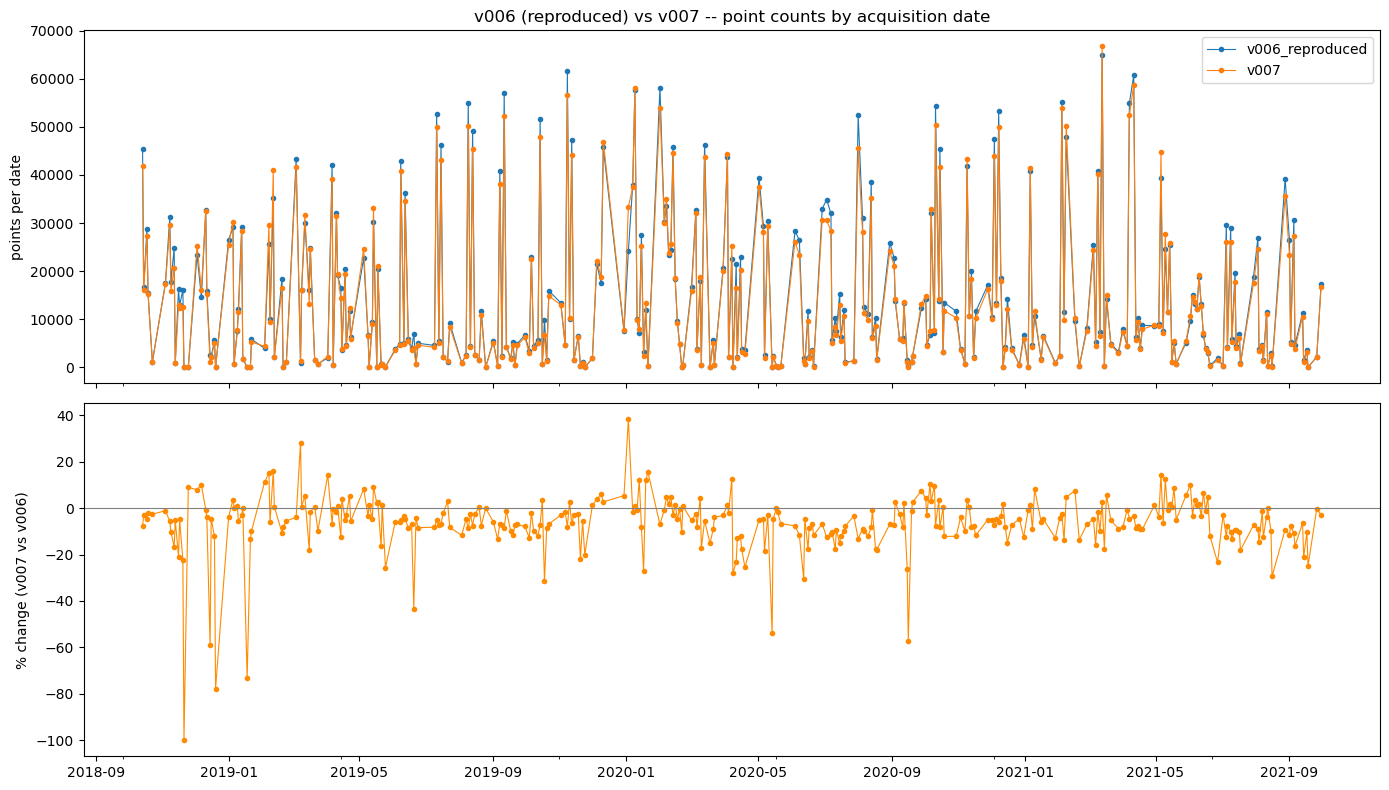

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

compare3[["v006_reproduced", "v007"]].plot(ax=axes[0], marker="o", ms=3, lw=0.8)
axes[0].set_ylabel("points per date")
axes[0].set_title("v006 (reproduced) vs v007 -- point counts by acquisition date")

compare3["pct_change"].plot(ax=axes[1], marker="o", ms=3, lw=0.8, color="darkorange")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_ylabel("% change (v007 vs v006)")

plt.tight_layout()

### Beyond point counts: did the actual values shift?

Point counts matching doesn't guarantee the *values* match -- different processing releases can
reclassify which photons count as ground/snow, shifting `h_mean` or `segment_snowcover` even where
counts line up. Individual points aren't guaranteed to correspond 1:1 between versions (segment
boundaries can differ), so compare per-date aggregate statistics instead of point-by-point.

h_mean daily-average difference (v007 - v006):
count    328.000000
mean       5.731460
std       43.124023
min     -240.151123
25%       -8.456940
50%        2.909149
75%       20.444794
max      289.780518
Name: h_mean_diff, dtype: float64

segment_snowcover daily-average difference (v007 - v006):
count    328.000000
mean       0.806103
std       14.024450
min       -0.077799
25%        0.000000
50%        0.000000
75%        0.022560
max      254.000000
Name: snowcover_diff, dtype: float64


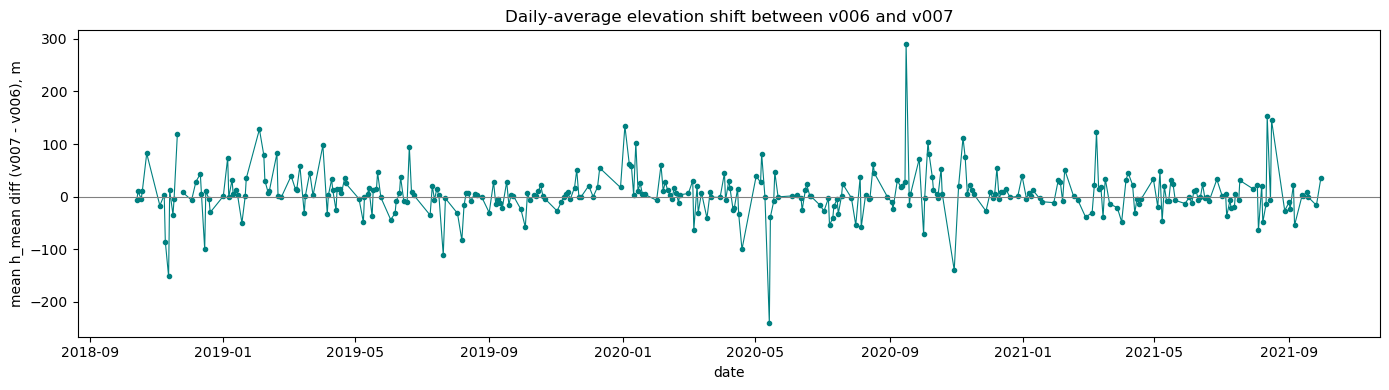

In [17]:
def daily_stats(gdf, label):
    d = pd.to_datetime(gdf.index).date
    out = pd.DataFrame({
        f"{label}_h_mean": gdf["h_mean"],
        f"{label}_snowcover": gdf["segment_snowcover"],
        "date": d,
    }).groupby("date").agg(["mean", "count"])
    out.columns = ["_".join(c) for c in out.columns]
    return out

stats_006 = daily_stats(new, "v006")
stats_007 = daily_stats(v007_clip, "v007")

value_compare = stats_006.join(stats_007, how="outer")
value_compare["h_mean_diff"] = value_compare["v007_h_mean_mean"] - value_compare["v006_h_mean_mean"]
value_compare["snowcover_diff"] = value_compare["v007_snowcover_mean"] - value_compare["v006_snowcover_mean"]

print("h_mean daily-average difference (v007 - v006):")
print(value_compare["h_mean_diff"].describe())
print("\nsegment_snowcover daily-average difference (v007 - v006):")
print(value_compare["snowcover_diff"].describe())

fig, ax = plt.subplots(figsize=(14, 4))
value_compare["h_mean_diff"].plot(ax=ax, marker="o", ms=3, lw=0.8, color="teal")
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("mean h_mean diff (v007 - v006), m")
ax.set_title("Daily-average elevation shift between v006 and v007")
plt.tight_layout()

### The daily-mean comparison above is misleading -- match on exact segments instead

The daily-average `h_mean` diff above hit **~290 m** on some dates (e.g. 2020-09-16), which is not a
believable processing-version effect. Checked that date directly: v006 kept 240 segments, v007 kept a
different, smaller set of 103 -- different populations of along-track segments over a region with a huge
elevation gradient (Sierra foothills to crest), so the two daily means are just averaging different
terrain, not the same points measured twice. Averaging "whatever survived filtering that day" confounds
real processing change with which segments each version happened to keep.

The fix: match on `rgt` + `cycle` + `gt` + `segment_id_beg`, which identify the same physical 40 m
along-track segment regardless of ATL03 processing release, and diff `h_mean` only for segments that
exist in both versions.

In [18]:
match_keys = ["rgt", "cycle", "gt", "segment_id_beg"]

m006 = new[match_keys + ["h_mean"]].rename(columns={"h_mean": "h_mean_006"})
m007 = v007_clip[match_keys + ["h_mean"]].rename(columns={"h_mean": "h_mean_007"})
matched = m006.merge(m007, on=match_keys, how="inner")

print(f"Exact-segment matches: {len(matched):,} "
      f"({len(matched)/len(new)*100:.1f}% of v006, {len(matched)/len(v007_clip)*100:.1f}% of v007)")

h_diff = matched["h_mean_007"] - matched["h_mean_006"]
print("\nh_mean difference (v007 - v006), matched segments only:")
print(h_diff.describe())
print(f"\nwithin 0.5 m: {(h_diff.abs() < 0.5).mean()*100:.1f}%")
print(f"within 2.0 m: {(h_diff.abs() < 2.0).mean()*100:.1f}%")

Exact-segment matches: 4,152,548 (89.3% of v006, 92.8% of v007)

h_mean difference (v007 - v006), matched segments only:
count    4.152548e+06
mean    -8.799738e-02
std      2.058458e+00
min     -6.377783e+01
25%     -4.653320e-01
50%     -4.614258e-02
75%      2.498779e-01
max      1.043605e+02
dtype: float64

within 0.5 m: 57.4%
within 2.0 m: 87.3%


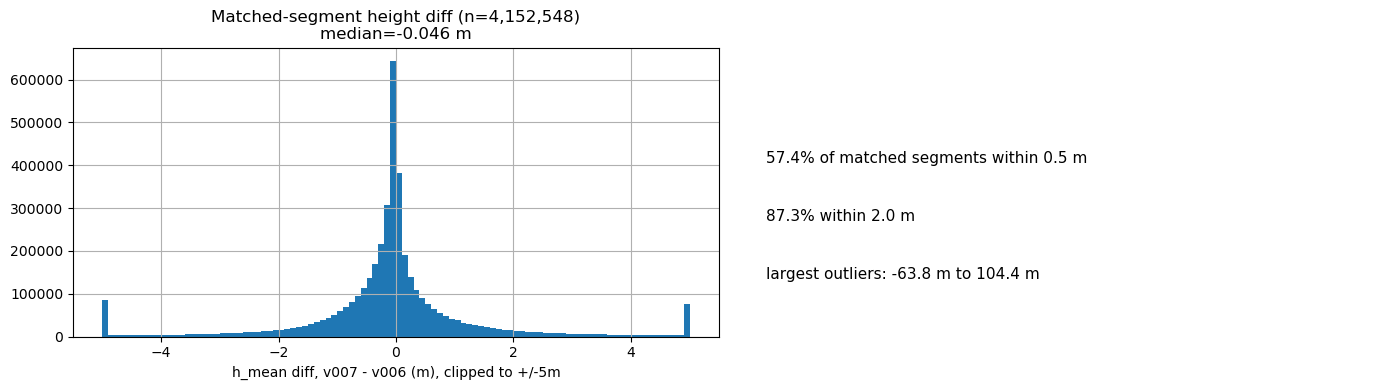

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

h_diff.clip(-5, 5).hist(bins=100, ax=axes[0])
axes[0].set_xlabel("h_mean diff, v007 - v006 (m), clipped to +/-5m")
axes[0].set_title(f"Matched-segment height diff (n={len(matched):,})\nmedian={h_diff.median():.3f} m")

axes[1].axis("off")
axes[1].text(0.05, 0.6, f"{(h_diff.abs() < 0.5).mean()*100:.1f}% of matched segments within 0.5 m", fontsize=11)
axes[1].text(0.05, 0.4, f"{(h_diff.abs() < 2.0).mean()*100:.1f}% within 2.0 m", fontsize=11)
axes[1].text(0.05, 0.2, f"largest outliers: {h_diff.min():.1f} m to {h_diff.max():.1f} m", fontsize=11)

plt.tight_layout()

## 6. Sanity check: does `3dep.value` itself change between versions?

`3dep.value` is sampled from the static USGS 3DEP 10 m bare-earth DEM at each segment's location -- it
isn't derived from ATLAS photons at all, so for the *same physical segment* it should be essentially
identical between ATL03 releases. The only way it could shift is if the segment's geolocation (lat/lon)
moved enough between v006 and v007 to sample a different DEM pixel -- e.g. from the ITRF2014 -> ITRF2020
reference frame change. This gives a noise floor to compare the `h_mean` and snow-depth differences
against: if `3dep.value` is essentially unchanged but `h_mean` moves more, that isolates the difference
to ATLAS photon processing (`quality_ph`/`weight_ph`) rather than geolocation drift.

Exact-segment matches: 4,152,548 (89.3% of v006, 92.8% of v007)

3dep.value difference (v007 - v006), matched segments:
count    4.152548e+06
mean    -3.847634e-02
std      2.209153e+00
min     -1.310091e+02
25%      1.558164e-03
50%      1.612616e-03
75%      1.661671e-03
max      1.175900e+02
dtype: float64

within 0.1 m: 68.2%
within 0.5 m: 73.8%


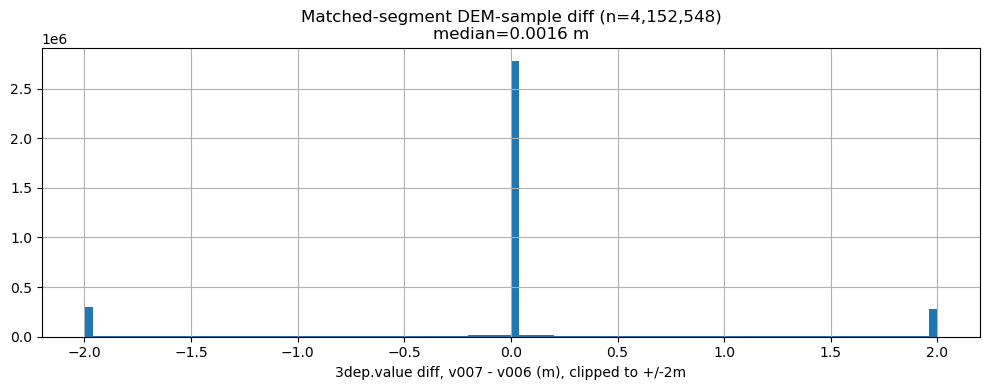

In [20]:
m006_dem = new[match_keys + ["3dep.value"]].rename(columns={"3dep.value": "dem_006"})
m007_dem = v007_clip[match_keys + ["3dep.value"]].rename(columns={"3dep.value": "dem_007"})
matched_dem = m006_dem.merge(m007_dem, on=match_keys, how="inner")

print(f"Exact-segment matches: {len(matched_dem):,} "
      f"({len(matched_dem)/len(new)*100:.1f}% of v006, {len(matched_dem)/len(v007_clip)*100:.1f}% of v007)")

dem_diff = matched_dem["dem_007"] - matched_dem["dem_006"]
print("\n3dep.value difference (v007 - v006), matched segments:")
print(dem_diff.describe())
print(f"\nwithin 0.1 m: {(dem_diff.abs() < 0.1).mean()*100:.1f}%")
print(f"within 0.5 m: {(dem_diff.abs() < 0.5).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
dem_diff.clip(-2, 2).hist(bins=100, ax=ax)
ax.set_xlabel("3dep.value diff, v007 - v006 (m), clipped to +/-2m")
ax.set_title(f"Matched-segment DEM-sample diff (n={len(matched_dem):,})\nmedian={dem_diff.median():.4f} m")
plt.tight_layout()

## 7. Snow depth proxy (`icesat2_3dep_dif = h_mean - 3dep.value`), Dec-Jun only

`3dep.value` is the sampled bare-earth DEM elevation, so `h_mean - 3dep.value` is a rough snow-depth
proxy (ICESat-2 surface minus bare ground). Restricting to December-June keeps this to the snow season
and avoids diluting the comparison with snow-free months where the difference should be ~0 by
construction. Same two-part comparison as `h_mean` above: daily median first (coarse, composition-
sensitive), then exact-segment matching (the real like-for-like comparison).

In [21]:
# Add the snow-depth-proxy column to all three dataframes
for gdf in (orig_clip, new, v007_clip):
    gdf["icesat2_3dep_dif"] = gdf["h_mean"] - gdf["3dep.value"]

winter_months = [12, 1, 2, 3, 4, 5, 6]

orig_winter = orig_clip[pd.to_datetime(orig_clip.index).month.isin(winter_months)]
new_winter = new[pd.to_datetime(new.index).month.isin(winter_months)]
v007_winter = v007_clip[pd.to_datetime(v007_clip.index).month.isin(winter_months)]

print(f"orig (Dec-Jun):  {len(orig_winter):,} of {len(orig_clip):,}")
print(f"v006 (Dec-Jun):  {len(new_winter):,} of {len(new):,}")
print(f"v007 (Dec-Jun):  {len(v007_winter):,} of {len(v007_clip):,}")

/opt/homebrew/Caskroom/miniforge/base/envs/sliderule_env/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/homebrew/Caskroom/miniforge/base/envs/sliderule_env/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


orig (Dec-Jun):  2,738,771 of 4,648,274
v006 (Dec-Jun):  2,741,665 of 4,651,168
v007 (Dec-Jun):  2,705,573 of 4,472,877


In [ ]:
def daily_median(gdf, label):
    d = pd.to_datetime(gdf.index).date
    out = pd.DataFrame({f"{label}_dif": gdf["icesat2_3dep_dif"], "date": d}).groupby("date").agg(["median", "count"])
    out.columns = ["_".join(c) for c in out.columns]
    return out

snow_006 = daily_median(new_winter, "v006")
snow_007 = daily_median(v007_winter, "v007")

snow_compare = snow_006.join(snow_007, how="outer")
snow_compare["dif_diff"] = snow_compare["v007_dif_median"] - snow_compare["v006_dif_median"]

print("Daily-median snow-depth-proxy difference (v007 - v006), Dec-Jun only:")
print(snow_compare["dif_diff"].describe())

# scatter, not a connected line -- Dec-Jun spans a year boundary and is separated from the next
# winter by a 5-month gap, so a line plot draws a misleading diagonal connecting each winter to the next
fig, ax = plt.subplots(figsize=(14, 4))
x = pd.to_datetime(snow_compare.index)
ax.scatter(x, snow_compare["v006_dif_median"], s=10, alpha=0.6, label="v006")
ax.scatter(x, snow_compare["v007_dif_median"], s=10, alpha=0.6, label="v007")
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("median icesat2_3dep_dif (m)")
ax.set_title("Daily-median snow-depth proxy, v006 vs v007 (Dec-Jun only)")
ax.legend()
plt.tight_layout()

As with `h_mean`, the daily-median comparison above is composition-sensitive (different segments
surviving each version's filtering, averaged over terrain/snowpack that varies a lot within a date). The
exact-segment match below is the fairer comparison.

Exact-segment matches (Dec-Jun): 2,507,615 (91.5% of v006 winter, 92.7% of v007 winter)

icesat2_3dep_dif difference (v007 - v006), matched segments, Dec-Jun only:
count    2.507615e+06
mean    -1.711760e-02
std      1.335543e+00
min     -5.469375e+01
25%     -4.172863e-01
50%     -3.040440e-02
75%      3.062605e-01
max      4.477364e+01
dtype: float64

median: -0.030 m
within 0.5 m: 58.1%
within 2.0 m: 91.1%


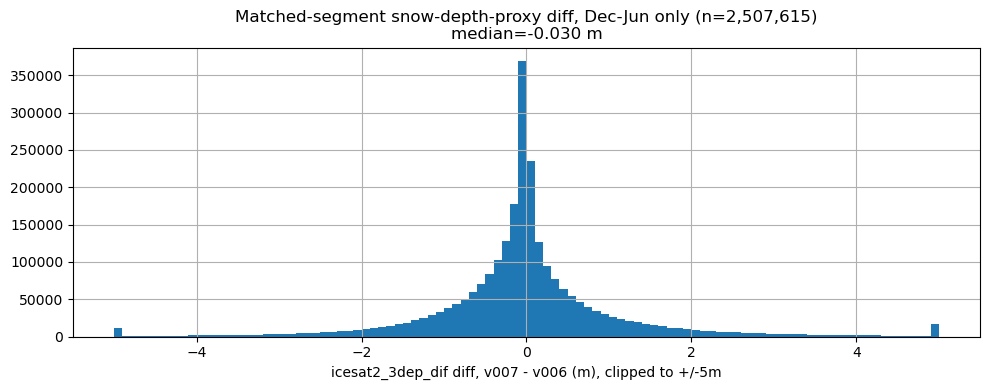

In [23]:
m006_snow = new_winter[match_keys + ["icesat2_3dep_dif"]].rename(columns={"icesat2_3dep_dif": "dif_006"})
m007_snow = v007_winter[match_keys + ["icesat2_3dep_dif"]].rename(columns={"icesat2_3dep_dif": "dif_007"})
matched_snow = m006_snow.merge(m007_snow, on=match_keys, how="inner")

print(f"Exact-segment matches (Dec-Jun): {len(matched_snow):,} "
      f"({len(matched_snow)/len(new_winter)*100:.1f}% of v006 winter, "
      f"{len(matched_snow)/len(v007_winter)*100:.1f}% of v007 winter)")

snow_diff = matched_snow["dif_007"] - matched_snow["dif_006"]
print("\nicesat2_3dep_dif difference (v007 - v006), matched segments, Dec-Jun only:")
print(snow_diff.describe())
print(f"\nmedian: {snow_diff.median():.3f} m")
print(f"within 0.5 m: {(snow_diff.abs() < 0.5).mean()*100:.1f}%")
print(f"within 2.0 m: {(snow_diff.abs() < 2.0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
snow_diff.clip(-5, 5).hist(bins=100, ax=ax)
ax.set_xlabel("icesat2_3dep_dif diff, v007 - v006 (m), clipped to +/-5m")
ax.set_title(f"Matched-segment snow-depth-proxy diff, Dec-Jun only (n={len(matched_snow):,})\nmedian={snow_diff.median():.3f} m")
plt.tight_layout()

## 8. Snow-off validation: `icesat2_3dep_dif` in Jul-Nov (no snow on the ground)

July-November should be snow-free in the Sierra Nevada, so `icesat2_3dep_dif` (ATLAS surface minus
bare-earth DEM) should sit close to 0 -- this checks how well each dataset's ATLAS ground detection
tracks the reference DEM absent any snowpack signal, independent of the v006/v007 comparison. Any
nonzero offset here is bias/noise baked into the method itself and should inform how the Dec-Jun snow
depths above are interpreted (e.g. a dataset with a +0.3 m summer bias probably has +0.3 m of spurious
"snow depth" baked into its winter numbers too).

In [24]:
summer_months = [7, 8, 9, 10, 11]

orig_summer = orig_clip[pd.to_datetime(orig_clip.index).month.isin(summer_months)]
new_summer = new[pd.to_datetime(new.index).month.isin(summer_months)]
v007_summer = v007_clip[pd.to_datetime(v007_clip.index).month.isin(summer_months)]

print(f"orig (Jul-Nov):  {len(orig_summer):,} of {len(orig_clip):,}")
print(f"v006 (Jul-Nov):  {len(new_summer):,} of {len(new):,}")
print(f"v007 (Jul-Nov):  {len(v007_summer):,} of {len(v007_clip):,}")

summer_stats = pd.DataFrame({
    "orig": orig_summer["icesat2_3dep_dif"].describe(),
    "v006_reproduced": new_summer["icesat2_3dep_dif"].describe(),
    "v007": v007_summer["icesat2_3dep_dif"].describe(),
})
print("\nicesat2_3dep_dif summary, Jul-Nov (snow-off):")
summer_stats

orig (Jul-Nov):  1,909,503 of 4,648,274
v006 (Jul-Nov):  1,909,503 of 4,651,168
v007 (Jul-Nov):  1,767,304 of 4,472,877

icesat2_3dep_dif summary, Jul-Nov (snow-off):


,orig,v006_reproduced,v007
count,1.909503e+06,1.909503e+06,1.767304e+06
mean,-2.010427e-01,-2.001260e-01,-2.324724e-01
std,2.722740e+00,2.724045e+00,2.848385e+00
min,-7.569262e+01,-7.445336e+01,-6.120492e+01
25%,-9.974188e-01,-9.998405e-01,-1.096288e+00
50%,-4.877102e-02,-4.636897e-02,-1.229431e-01
75%,7.232633e-01,7.271485e-01,6.170624e-01
max,6.700901e+01,6.698602e+01,8.980698e+01


In [25]:
for label, gdf in [("orig", orig_summer), ("v006_reproduced", new_summer), ("v007", v007_summer)]:
    d = gdf["icesat2_3dep_dif"]
    print(f"{label:16s}  median={d.median():+.3f} m   "
          f"within 0.5m={ (d.abs() < 0.5).mean()*100:5.1f}%   "
          f"within 1.0m={ (d.abs() < 1.0).mean()*100:5.1f}%")

orig              median=-0.049 m   within 0.5m= 34.8%   within 1.0m= 55.0%
v006_reproduced   median=-0.046 m   within 0.5m= 34.7%   within 1.0m= 54.9%
v007              median=-0.123 m   within 0.5m= 34.9%   within 1.0m= 54.9%


In [28]:
print(f"{'dataset':16s} {'mean':>8s} {'median':>8s}   {'>2m':>6s} {'>5m':>6s} {'>10m':>6s}   {'<-2m':>6s} {'<-5m':>6s} {'<-10m':>6s}")
for label, gdf in [("orig", orig_summer), ("v006_reproduced", new_summer), ("v007", v007_summer)]:
    d = gdf["icesat2_3dep_dif"]
    print(f"{label:16s} {d.mean():8.3f} {d.median():8.3f}   "
          f"{(d > 2).mean()*100:5.2f}% {(d > 5).mean()*100:5.2f}% {(d > 10).mean()*100:5.2f}%   "
          f"{(d < -2).mean()*100:5.2f}% {(d < -5).mean()*100:5.2f}% {(d < -10).mean()*100:5.2f}%")

dataset              mean   median      >2m    >5m   >10m     <-2m   <-5m  <-10m
orig               -0.201   -0.049    9.36%  1.37%  0.36%   13.84%  2.90%  0.41%
v006_reproduced    -0.200   -0.046    9.42%  1.38%  0.36%   13.91%  2.91%  0.41%
v007               -0.232   -0.123    9.24%  1.78%  0.47%   14.54%  2.83%  0.34%


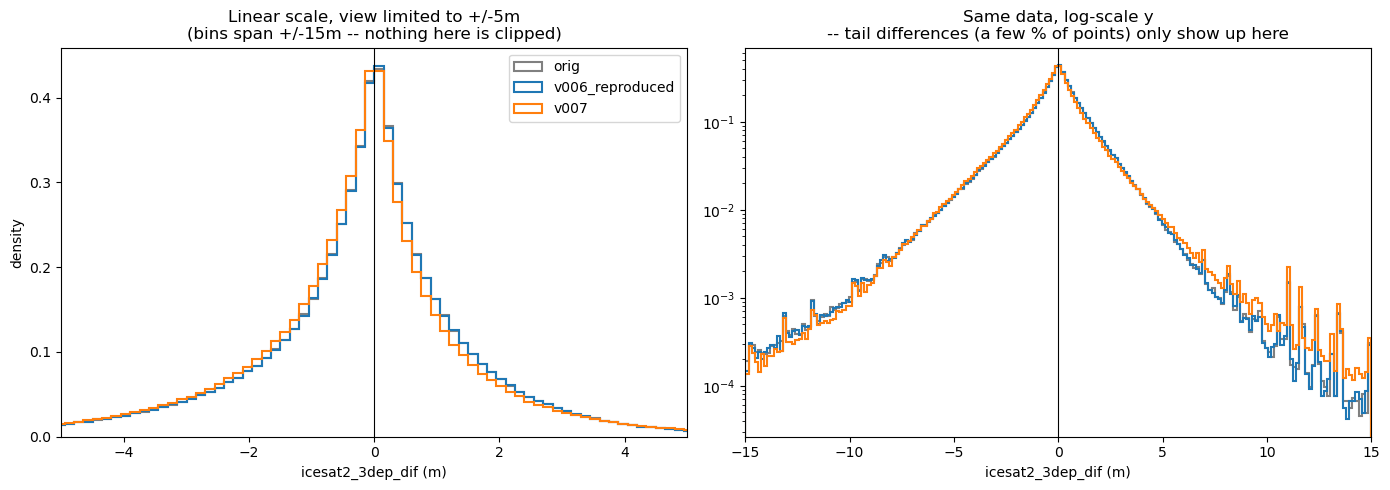

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = 200
hist_range = (-15, 15)  # bin over a wide range so no tail mass gets piled onto a clip edge

for label, gdf, color in [("orig", orig_summer, "gray"), ("v006_reproduced", new_summer, "tab:blue"), ("v007", v007_summer, "tab:orange")]:
    d = gdf["icesat2_3dep_dif"]
    axes[0].hist(d, bins=bins, range=hist_range, density=True, histtype="step", lw=1.5, label=label, color=color)
    axes[1].hist(d, bins=bins, range=hist_range, density=True, histtype="step", lw=1.5, label=label, color=color)

axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlim(-5, 5)
axes[0].set_xlabel("icesat2_3dep_dif (m)")
axes[0].set_ylabel("density")
axes[0].set_title("Linear scale, view limited to +/-5m\n(bins span +/-15m -- nothing here is clipped)")
axes[0].legend()

axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_xlim(-15, 15)
axes[1].set_xlabel("icesat2_3dep_dif (m)")
axes[1].set_title("Same data, log-scale y\n-- tail differences (a few % of points) only show up here")

plt.tight_layout()

### Interpreting this

**The spikes exactly at the +/-5m edges in the original filled histogram were a clipping artifact**,
not a real feature: `.clip(-5, 5)` piles every point beyond that range into a single edge bin, which
exaggerates whichever dataset happens to have more extreme outliers into a dramatic-looking spike right
at the boundary. The step/log-scale version above bins the real range so nothing gets artificially
stacked at an edge.

**Checking the actual numbers (Jul-Nov, this run): the heavier tail is on the *positive* side, not the
left** -- v007 has *more* points above +5m (1.78% vs 1.38% for v006) and above +10m (0.47% vs 0.36%),
despite v007 having *fewer* total summer points overall (1.77M vs 1.89M), so the effect is real, not a
sample-size artifact. On the negative side v007 is roughly comparable to v006 in the extreme tail
(2.83% vs 2.89% beyond -5m) but has *more* mass in the moderate range around -1 to -2m. Both the mean
(-0.23 m vs -0.20 m) and median (-0.12 m vs -0.05 m) are slightly more negative in v007 -- a small but
real shift, not just noise.

One plausible explanation tied to the [release notes](https://nsidc.org/sites/default/files/documents/user-guide/atl03-v007-userguide.pdf)
we found earlier: v7 overhauled `quality_ph` (new flags for noise bursts/streaks and saturated pulses,
and **v6's flag values of 1 and 2 are explicitly obsolete in v7**). If SlideRule's `atl03x` processing
filters on `quality_ph` using logic written for v6's flag semantics, it could be interpreting some of
v7's repurposed flag values differently than intended, letting a different -- and apparently somewhat
larger -- population of outlier photons through as "ground" signal in both directions. This is a
hypothesis based on the documented flag change, not something verified against SlideRule's internal
filtering code.

In [ ]:
# reuses daily_median() from the snow-depth section above -- same function, just fed the summer subsets
summer_daily_orig = daily_median(orig_summer, "orig")
summer_daily_006 = daily_median(new_summer, "v006")
summer_daily_007 = daily_median(v007_summer, "v007")

summer_daily = summer_daily_orig.join(summer_daily_006, how="outer").join(summer_daily_007, how="outer")

# scatter, not a connected line -- Jul-Nov is separated from the next year's window by a 7-month
# gap (Dec-Jun), so a line plot draws a misleading diagonal connecting each year to the next
fig, ax = plt.subplots(figsize=(14, 4))
x = pd.to_datetime(summer_daily.index)
ax.scatter(x, summer_daily["orig_dif_median"], s=10, alpha=0.5, label="orig", color="gray")
ax.scatter(x, summer_daily["v006_dif_median"], s=10, alpha=0.5, label="v006_reproduced")
ax.scatter(x, summer_daily["v007_dif_median"], s=10, alpha=0.5, label="v007")
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("median icesat2_3dep_dif (m)")
ax.set_title("Daily-median snow-off residual (Jul-Nov), by dataset")
ax.legend()
plt.tight_layout()